In [1]:
#Import libraries

import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [17]:
#Load and read the data

file = "U:/EDS Capstone/UTCI/10_high_utci_days-reanalysis-monthly-grid-1940-2023-v1.0.nc"
ds = xr.open_dataset(file)

In [19]:
#Understanding data structure

print(ds)
print(ds.data_vars)
print(ds.coords)

<xarray.Dataset>
Dimensions:         (time: 1008, height: 1, lon: 271, lat: 185)
Coordinates:
  * time            (time) datetime64[ns] 1940-01-01 1940-02-01 ... 2023-12-01
  * height          (height) float64 2.0
  * lon             (lon) float64 -22.0 -21.75 -21.5 -21.25 ... 45.0 45.25 45.5
  * lat             (lat) float64 26.5 26.75 27.0 27.25 ... 72.0 72.25 72.5
Data variables:
    high_utci_days  (time, lat, lon, height) int64 ...
Data variables:
    high_utci_days  (time, lat, lon, height) int64 ...
Coordinates:
  * time     (time) datetime64[ns] 1940-01-01 1940-02-01 ... 2023-12-01
  * height   (height) float64 2.0
  * lon      (lon) float64 -22.0 -21.75 -21.5 -21.25 ... 44.75 45.0 45.25 45.5
  * lat      (lat) float64 26.5 26.75 27.0 27.25 27.5 ... 71.75 72.0 72.25 72.5


In [21]:
#Slicing data from 2000 to 2023 over the Europe

europe_24y = ds.sel(time=slice("2000-01-01", "2023-12-31"))
print(europe_24y.time.min().values, europe_24y.time.max().values)

2000-01-01T00:00:00.000000000 2023-12-01T00:00:00.000000000


In [13]:
#Save sliced data 

europe_24y.to_netcdf(r"U:/EDS Capstone/UTCI/europe_2004_2023.nc")

In [23]:
#Variable in the data set
var = "high_utci_days"   # replace with your real variable name
da = europe_24y[var]
print(da)

<xarray.DataArray 'high_utci_days' (time: 288, lat: 185, lon: 271, height: 1)>
[14438880 values with dtype=int64]
Coordinates:
  * time     (time) datetime64[ns] 2000-01-01 2000-02-01 ... 2023-12-01
  * height   (height) float64 2.0
  * lon      (lon) float64 -22.0 -21.75 -21.5 -21.25 ... 44.75 45.0 45.25 45.5
  * lat      (lat) float64 26.5 26.75 27.0 27.25 27.5 ... 71.75 72.0 72.25 72.5
Attributes:
    units:    1
    comment:  derived from hourly ERA5-HEAT data


In [59]:
# Mean time series over the Europe

eu_mean_ts = da.mean(dim=["lat", "lon"])

print(eu_mean_ts)

<xarray.DataArray 'high_utci_days' (time: 288, height: 1)>
array([[1.69542236e-03],
       [2.53914431e-02],
       [6.50423856e-01],
       [2.31207739e+00],
       [3.45684651e+00],
       [5.14255510e+00],
       [6.26803630e+00],
       [6.84822978e+00],
       [4.51038197e+00],
       [2.06394734e+00],
       [3.88132043e-01],
       [1.13294106e-02],
       [1.77520694e-03],
       [5.75645756e-02],
       [1.55607859e+00],
       [1.99182208e+00],
       [3.28319537e+00],
       [4.67469831e+00],
       [7.82678767e+00],
       [7.51203750e+00],
...
       [3.70878628e+00],
       [5.95123167e+00],
       [8.15926997e+00],
       [8.81587713e+00],
       [5.08676573e+00],
       [3.19988032e+00],
       [5.21013264e-01],
       [1.90485689e-01],
       [4.08895981e-03],
       [9.28692530e-02],
       [1.27096839e+00],
       [2.31794156e+00],
       [3.19098434e+00],
       [4.89637977e+00],
       [7.85848210e+00],
       [8.67579535e+00],
       [5.43789768e+00],
       [3.89

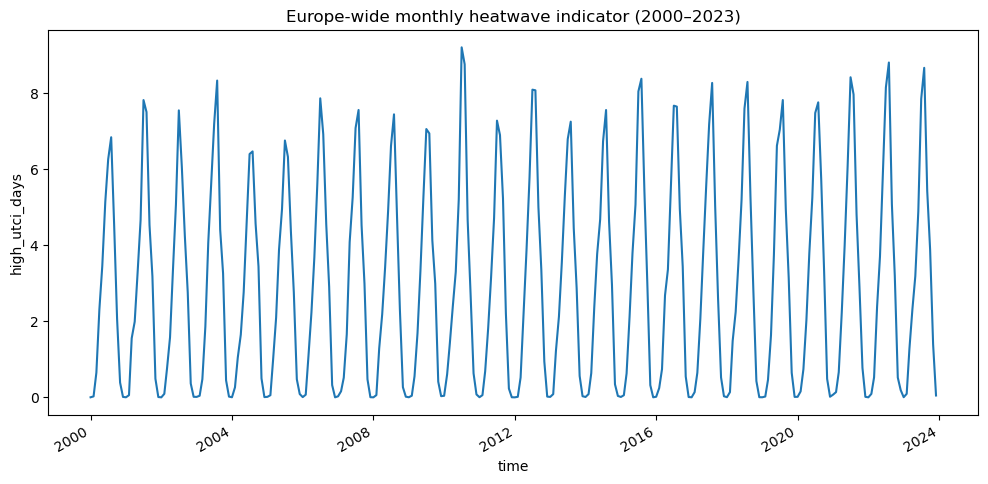

In [27]:
# Europe-wode monthly heatwave days over the year 2000 to 2023

plt.figure(figsize=(12, 5))
eu_mean_ts.plot()
plt.title("Europe-wide monthly heatwave indicator (2000–2023)")
plt.ylabel(var)
plt.show()

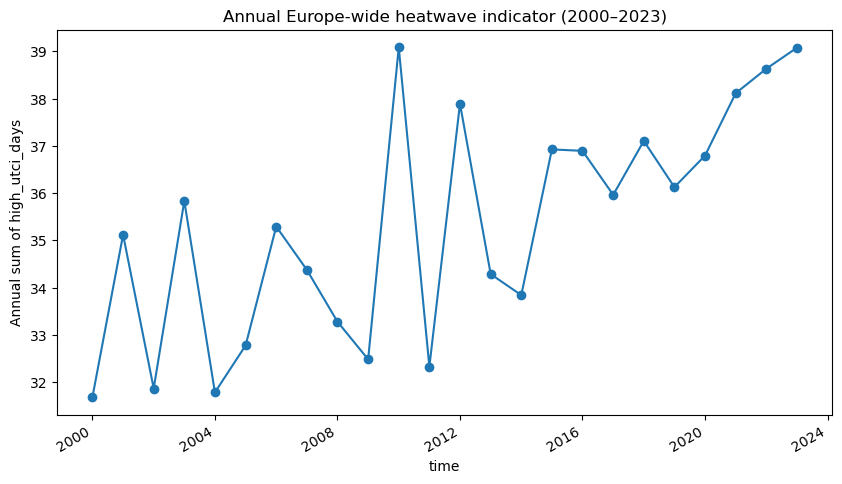

In [39]:
# Annual heatwave days in Europe over the year 2000 to 2023

annual = da.resample(time="YS").sum()
annual_eu = annual.mean(dim=["lat", "lon"])

plt.figure(figsize=(10, 5))
annual_eu.plot(marker="o")
plt.title("Annual Europe-wide heatwave indicator (2000–2023)")
plt.ylabel(f"Annual sum of {var}")
plt.show()

In [41]:
# Resample data

annual_mean = da.resample(time="YS").mean()
annual_mean_eu = annual_mean.mean(dim=["lat", "lon"])

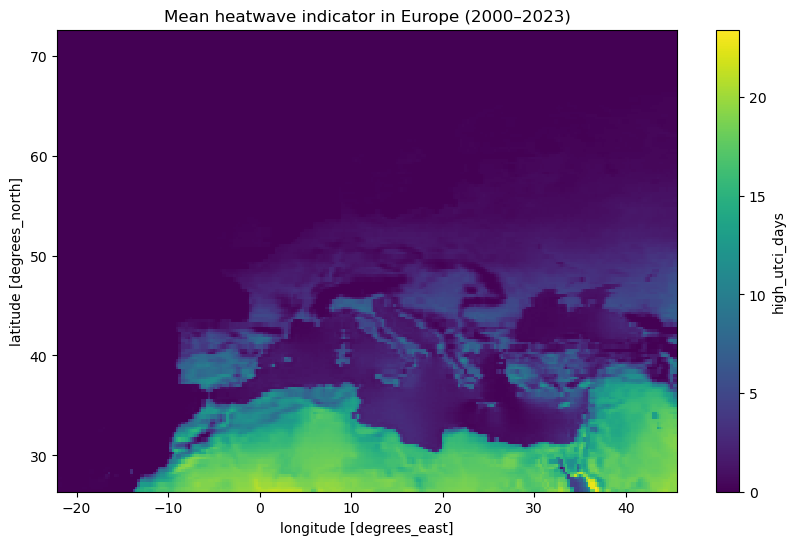

In [37]:
# Spatial variation  of mean heatwave days over Europe from the year 2000 to 2023

mean_map = da.mean(dim="time")

plt.figure(figsize=(10, 6))
mean_map.plot(cbar_kwargs={"label": var})
plt.title("Mean heatwave indicator in Europe (2000–2023)")
plt.show()

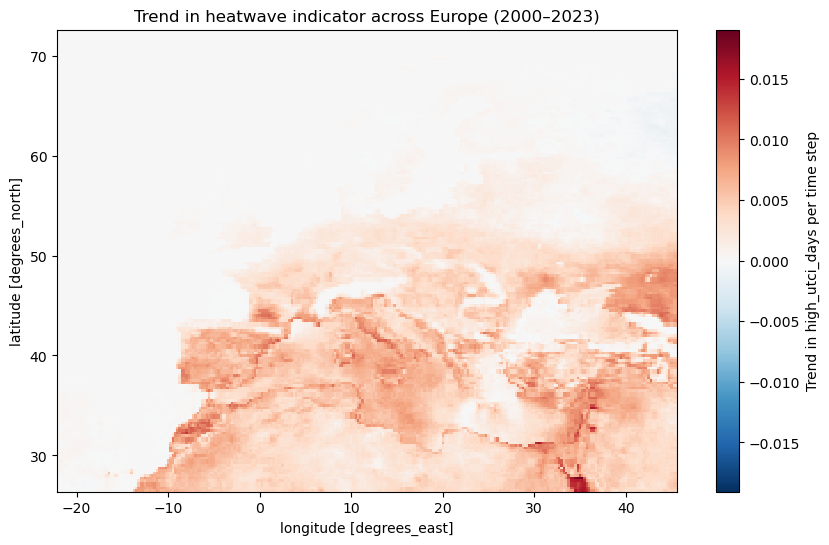

In [43]:
# convert time to numeric index
t = np.arange(da.sizes["time"])

def lintrend(y):
    mask = np.isfinite(y)
    if mask.sum() < 2:
        return np.nan
    return np.polyfit(t[mask], y[mask], 1)[0]

trend = xr.apply_ufunc(
    lintrend,
    da,
    input_core_dims=[["time"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float]
)

plt.figure(figsize=(10, 6))
trend.plot(cbar_kwargs={"label": f"Trend in {var} per time step"})
plt.title("Trend in heatwave indicator across Europe (2000–2023)")
plt.show()

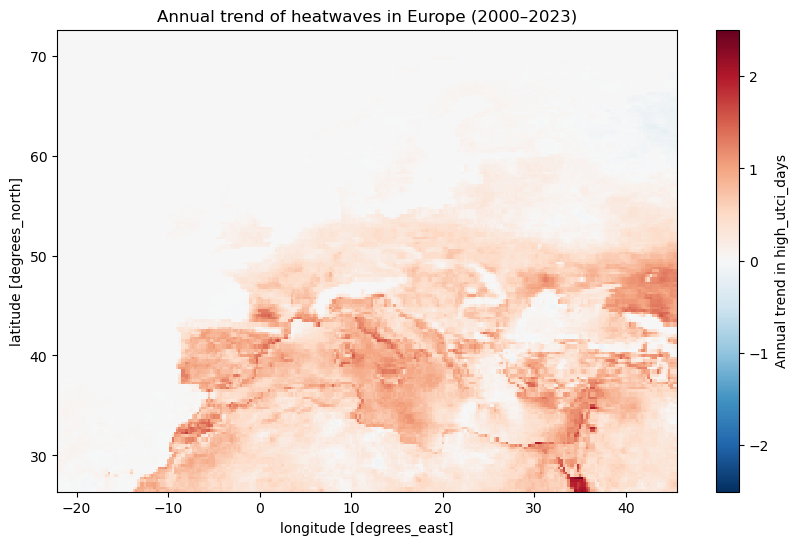

In [45]:
# Annual trend of heatwave over Europe from the year 2000 to 2023

annual_da = da.resample(time="YS").sum()
t_ann = np.arange(annual_da.sizes["time"])

def lintrend_ann(y):
    mask = np.isfinite(y)
    if mask.sum() < 2:
        return np.nan
    return np.polyfit(t_ann[mask], y[mask], 1)[0]

trend_ann = xr.apply_ufunc(
    lintrend_ann,
    annual_da,
    input_core_dims=[["time"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float]
)

plt.figure(figsize=(10, 6))
trend_ann.plot(cbar_kwargs={"label": f"Annual trend in {var}"})
plt.title("Annual trend of heatwaves in Europe (2000–2023)")
plt.show()

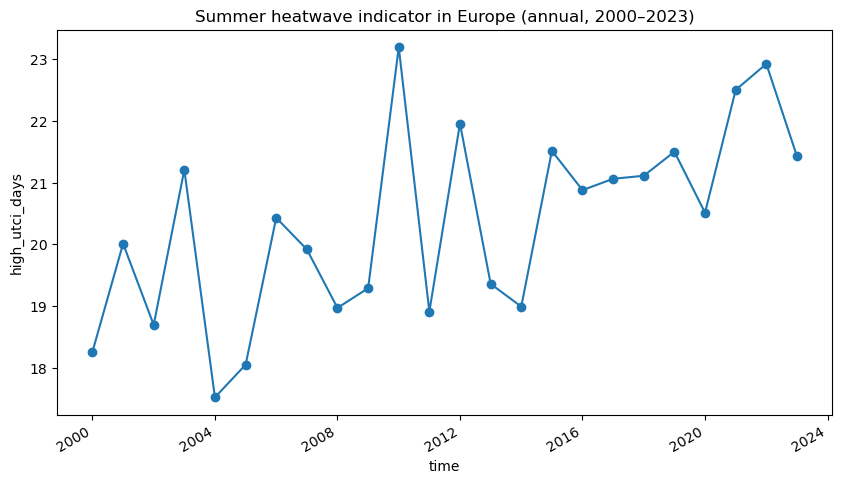

In [47]:
# Summertime heatwave over Europe from the year 2000 to 2023

summer = da.where(da["time"].dt.month.isin([6, 7, 8]), drop=True)

summer_annual = summer.resample(time="YS").sum()
summer_eu = summer_annual.mean(dim=["lat", "lon"])

plt.figure(figsize=(10, 5))
summer_eu.plot(marker="o")
plt.title("Summer heatwave indicator in Europe (annual, 2000–2023)")
plt.ylabel(var)
plt.show()

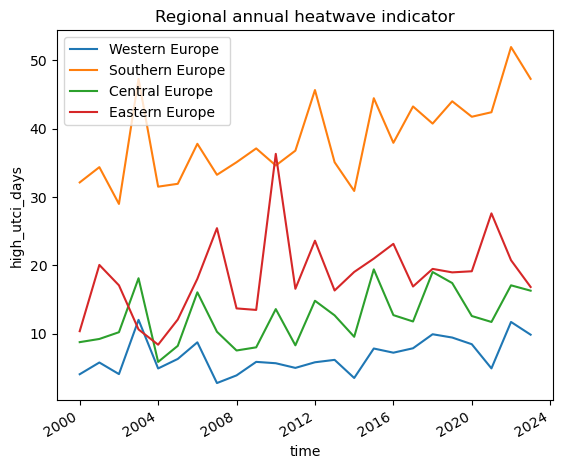

In [57]:
# Regional variation of heatwave days over Europe from the year 2000 to 2023

regions = {
    "Western Europe": dict(lon=slice(-10, 10), lat=slice(42, 60)),
    "Southern Europe": dict(lon=slice(-10, 30), lat=slice(34, 46)),
    "Central Europe": dict(lon=slice(5, 25), lat=slice(46, 56)),
    "Eastern Europe": dict(lon=slice(20, 45), lat=slice(45, 60)),
}

for name, box in regions.items():
    reg = da.sel(lon=box["lon"], lat=box["lat"])
    reg_ts = reg.mean(dim=["lat", "lon"]).resample(time="YS").sum()
    reg_ts.plot(label=name)

plt.legend(loc = 'upper left')
plt.title("Regional annual heatwave indicator")
plt.show()